<a href="https://colab.research.google.com/github/CH3MLON/Data_GenAI_training/blob/main/day9/Day09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.5 MB/s eta 0:00:00


In [ ]:
import sqlite3
import pandas as pd
import re
from groq import Groq
import os

In [ ]:
os.environ["GROQ_API_KEY"]="your_api_key"
client=Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL="llama-3.1-8b-instant"
print("client model initialized")

client model initialized


In [ ]:
import io
ds=pd.read_csv("/content/student_performance.csv")
ds.shape

(30, 13)

In [ ]:
conn = sqlite3.connect("college.db")
ds.to_sql("students",conn, if_exists="replace",index=False)

30

In [ ]:
test_ds=pd.read_sql_query("SELECT COUNT(*) as total_rows from students",conn)
print(f"Verification: {test_ds['total_rows'][0]}")

Verification: 30


In [ ]:
def get_schema(conn, table_name="students"):
  "this is for your description"
  cursor=conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})")
  columns=cursor.fetchall()
  schema_lines=[f"Table: {table_name}"]
  schema_lines.append("Columns:")

  for col in columns:
    schema_lines.append(f"({col[1]})({col[2]})")
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows=cursor.fetchall()
  schema_lines.append("\n Sample rows(first 3): ")

  for row in sample_rows:
    schema_lines.append(f" {row}")
  return "\n".join(schema_lines)

schema= get_schema(conn)
print(schema)

Table: students
Columns:
(student_id)(INTEGER)
(name)(TEXT)
(age)(INTEGER)
(gender)(TEXT)
(department)(TEXT)
(semester)(INTEGER)
(math_score)(INTEGER)
(science_score)(INTEGER)
(english_score)(INTEGER)
(programming_score)(INTEGER)
(attendance_percentage)(INTEGER)
(city)(TEXT)
(admission_year)(INTEGER)

 Sample rows(first 3): 
 (1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)
 (1002, 'Priya Patel', 20, 'Female', 'Computer Science', 2, 76, 82, 88, 79, 87, 'Ahmedabad', 2023)
 (1003, 'Rohit Verma', 19, 'Male', 'Electronics', 2, 65, 74, 61, 55, 78, 'Delhi', 2023)


In [ ]:
def generate_sql(user_question, schema_text, client, model):
  system_prompt=f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure

  {schema_text}

  RULES:
  1.generate only a valid salite sql query.
  2.do not include any explanation or text - only the sql query
  3.do not use markdown code blocks. return the rqw sql only
  4.the table name is students
  5.only use columns that exist in  the schema
  6.use single quotes for string values in WHERE clause (example: WHERE subject='Programming')
  7.if the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """

  response=client.chat.completions.create(
      model=model, #from where you are gonna get your response from
      messages=[
          {"role":"system", "content":system_prompt},
          {"role":"user", "content":user_question}
      ],

      temperature=0.0
  )
  sql_query=response.choices[0].message.content
  return sql_query

question="i need the top 3 performing students name in math with score"
sql=generate_sql(question,schema,client,MODEL)
print(f"\nsql query: {sql}")


sql query: SELECT name, math_score FROM students ORDER BY math_score DESC LIMIT 3


In [ ]:
def execute_sql(sql_query, conn):
  #cleans the AI-generated sql and executes it on the sqlite database returns the result as a pandas dataframe

  clean_sql=sql_query.strip()#clean the whitespace
  clean_sql=re.sub(r'```sql\s*', '',clean_sql)#substituting the following unecessary tags

  clean_sql=re.sub(r'```\s*', '',clean_sql)
  clean_sql=clean_sql.strip()

  try:

    result_ds=pd.read_sql_query(clean_sql,conn)
    return result_ds, None

  except Exception as e:
    return None, str(e)

print(f"Excecutiing SQL: {sql}")
result, error = execute_sql(sql,conn)

if error:
  print(f"Error: {error}")
else:
  print(f"\nQerry returned {len(result)} rows:")
  print(result.head())



Excecutiing SQL: SELECT name, math_score FROM students ORDER BY math_score DESC LIMIT 3

Qerry returned 3 rows:
          name  math_score
0   Ananya Das          95
1  Tanvi Mehta          93
2   Arjun Nair          92


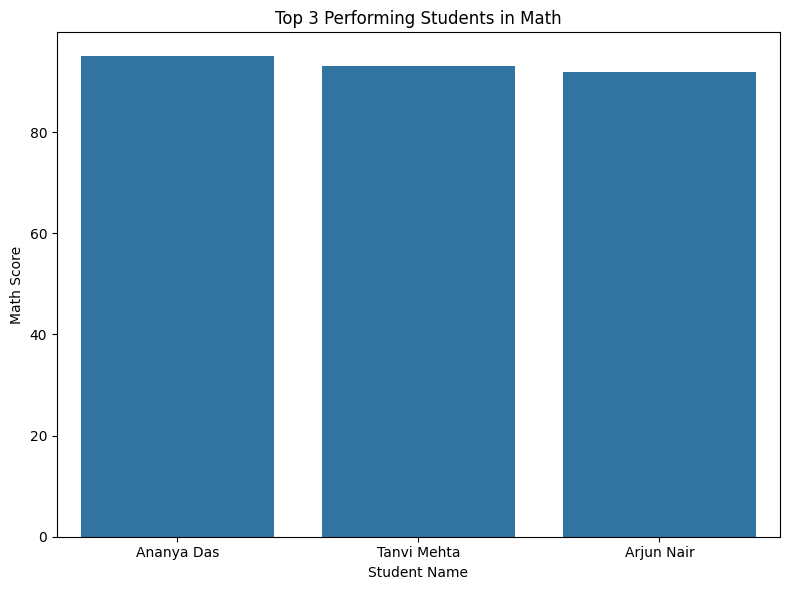

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='name', y='math_score', data=result, ax=ax)
ax.set_title('Top 3 Performing Students in Math')
ax.set_xlabel('Student Name')
ax.set_ylabel('Math Score')

plt.tight_layout()
plt.show()